# Project-6: Car Price Prediction

## Task 1: Dataset Overview

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\github\python-data-science-handbook\Projects\data\car data.csv")
print("Data Shape:", df.shape)
print("Column Names:", df.columns)
print("Data Info:", df.info())

Data Shape: (301, 9)
Column Names: Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
Data Info: None


## Task 2: Data Quality Check

In [4]:
print(df.isnull().sum())
df.drop_duplicates(inplace=True)

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [5]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


## Task 3: Understanding The Target Variable

In [7]:
# What is the average selling price?
mean_price = df["Selling_Price"].mean()
print("Average Selling Price:", mean_price)

Average Selling Price: 4.589632107023411


In [8]:
# What is the median selling price?
median_price = df["Selling_Price"].median()
print("Median Selling Price:", median_price)

Median Selling Price: 3.51


In [10]:
# What is the minimum and maximum selling price?
min_price = df["Selling_Price"].min()
max_price = df["Selling_Price"].max()
print("Minimum Selling Price:", min_price)
print("Maximum Selling Price:", max_price)

Minimum Selling Price: 0.1
Maximum Selling Price: 35.0


## Task 4: Distribution Analysis

Text(0, 0.5, 'Number of Cars')

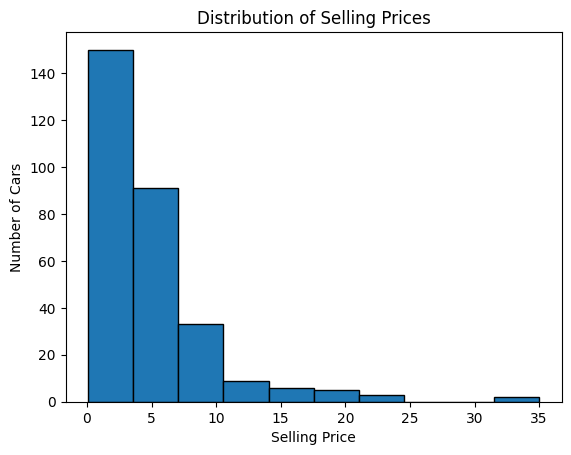

In [18]:
plt.hist(df["Selling_Price"], edgecolor="black")

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

## Task 5: Car Age Analysis

In [19]:
# New Column for Car Age
current_year = 2026
df["Car_Age"] = current_year - df["Year"]

In [20]:
# What is the oldest car in the Dataset?
oldest_car = df["Car_Age"].max()
print("Oldest Car Age:", oldest_car)

Oldest Car Age: 23


In [22]:
# What is the newest car?
newest_car = df["Car_Age"].min()
print("Newest Car Age:", newest_car)


# Does age appear to influence selling price?
average_age = df["Car_Age"].mean()
print("Average Car Age:", average_age)

Newest Car Age: 8
Average Car Age: 12.384615384615385


Text(0, 0.5, 'Selling Price')

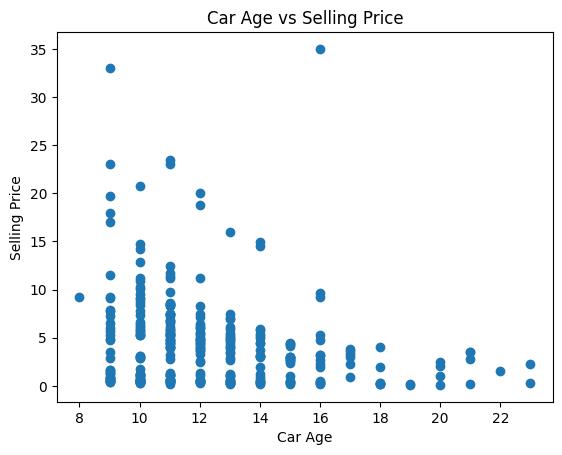

In [23]:
plt.scatter(df["Car_Age"], df["Selling_Price"])

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

## Task 6: Relationship Between Age and Price

In [33]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [35]:
df[["Car_Age", "Selling_Price"]].corr()

,Car_Age,Selling_Price
Car_Age,1.000000,-0.234369
Selling_Price,-0.234369,1.000000


## Task 7: Kilometers Driven Analysis

In [25]:
# What is the average distance driven?

avg_km = df["Kms_Driven"].mean()
print("Average Distance Driven:", avg_km)

# Which car has the highest mileage?
highest_km = df["Kms_Driven"].max()
print("Highest Mileage:", highest_km)

Average Distance Driven: 36916.752508361205
Highest Mileage: 500000


Text(0, 0.5, 'Selling Price')

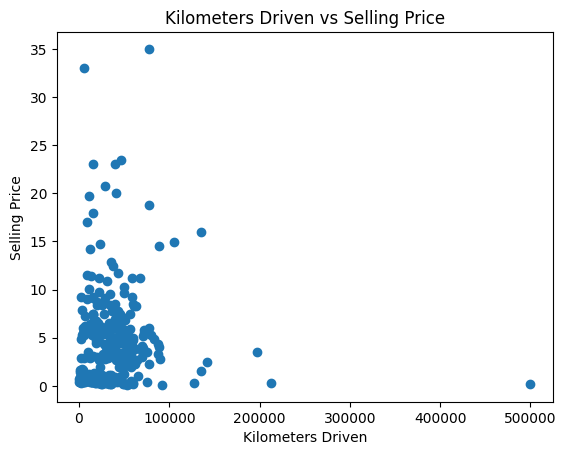

In [26]:
# Does Milage affect the selling price?

plt.scatter(df["Kms_Driven"], df["Selling_Price"])
plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

## Task 8: Fuel Type Investigation

In [27]:
# Which fuel type appears most frequently?
fuel_count = df["Fuel_Type"].value_counts()
print(fuel_count)

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64


In [36]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [37]:
fuel_price = df.groupby(by="Fuel_Type")["Selling_Price"].mean()
print(fuel_price)

Fuel_Type
CNG        3.100000
Diesel    10.102759
Petrol     3.264184
Name: Selling_Price, dtype: float64


## Task 9: Transmission Analysis

In [29]:
# How many cars are Manual? 
transmission_count = df["Transmission"].value_counts()
print(transmission_count)

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [ ]:
# Which transmission type has a higher average selling price?


## Task 10: Seller Type Analysis

In [30]:
# Which seller type dominates the dataset?
seller_count = df["Seller_Type"].value_counts()
print(seller_count)

Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64


Seller_Type
Dealer        6.632021
Individual    0.870943
Name: Selling_Price, dtype: float64


Text(0, 0.5, 'Count')

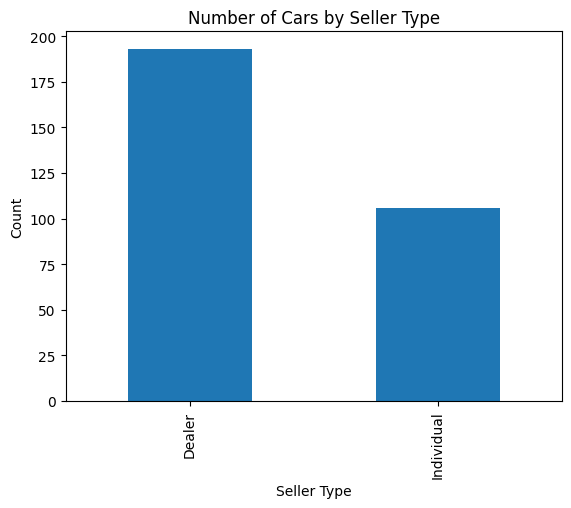

In [31]:
seller_price = df.groupby("Seller_Type")["Selling_Price"].mean()
print(seller_price)

seller_count.plot(kind="bar")

plt.title("Number of Cars by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Count")


## Task 11: Correlation Study

In [43]:
corr = df.corr(numeric_only=True)["Selling_Price"].sort_values()
corr

Car_Age         -0.234369
Owner           -0.087880
Kms_Driven       0.028566
Year             0.234369
Present_Price    0.876378
Selling_Price    1.000000
Name: Selling_Price, dtype: float64

## Task 12: Outlier Detection

In [44]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


{'whiskers': [<matplotlib.lines.Line2D at 0x1ea9c80ac00>,
 'caps': [<matplotlib.lines.Line2D at 0x1ea9c80b2f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ea99869220>],
 'medians': [<matplotlib.lines.Line2D at 0x1ea9c80b380>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ea9c80bb90>],
 'means': []}

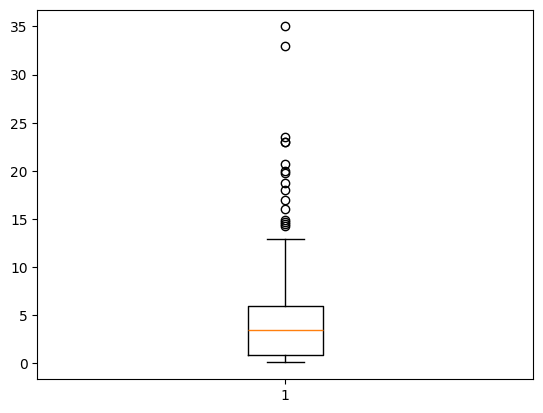

In [45]:
plt.boxplot(df["Selling_Price"])

In [46]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='object')

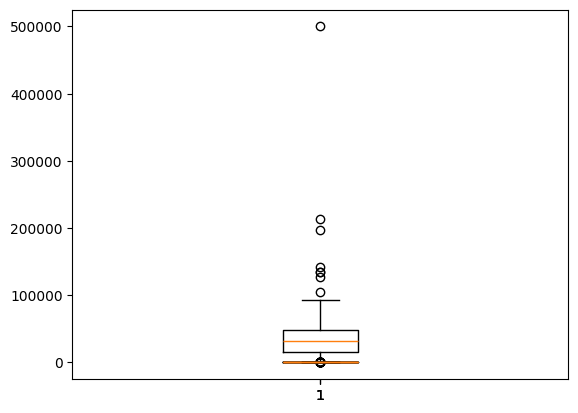

In [47]:
col_names = ["Selling_Price", "Present_Price", "Kms_Driven", "Car_Age"]

for i in col_names:
    plt.boxplot(df[i])

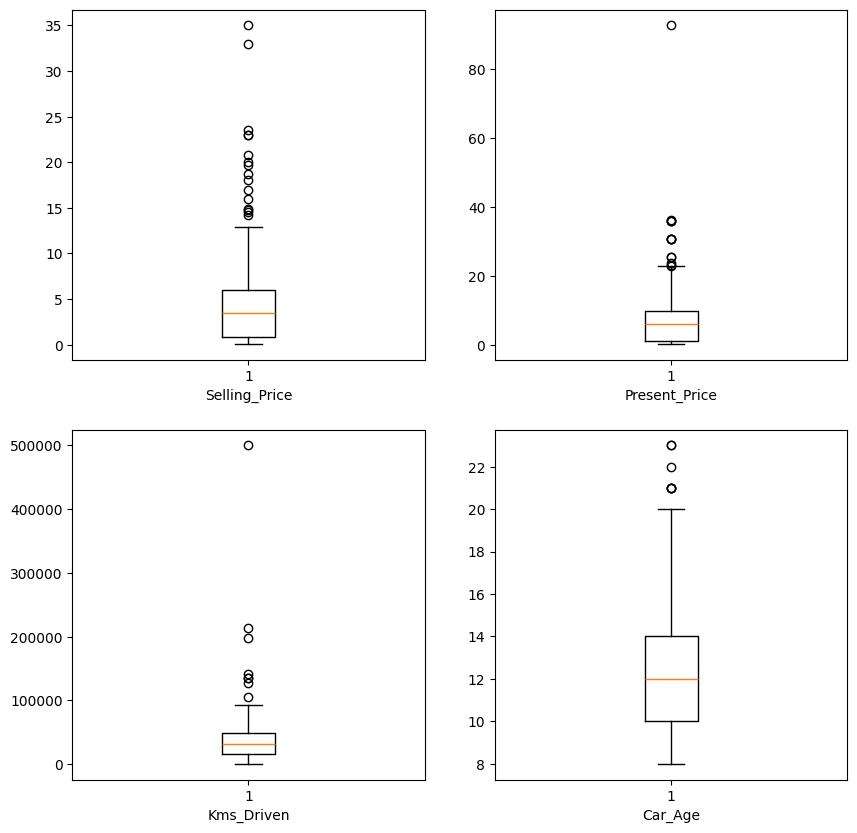

In [55]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(col_names):
    axes[i].boxplot(df[col])
    axes[i].set_xlabel(col)

